# ==============================
# PROJECT SETUP
# ==============================

In [84]:
#  ==========================================
#  Load required libraries
#  ==========================================
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from pathlib import Path
from IPython.display import display


In [2]:
# ==========================================
# Path and configuration setup
# ==========================================

# The notebook is inside notebooks/, so its parent folder is the repository root.
PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

# Ensure the destination exists before downloading files.
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)

NHANES_DATASETS = {
    "demographics": {
        "filename": "P_DEMO.XPT",
        "url": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DEMO.XPT",
    },
    "body_measures": {
        "filename": "P_BMX.XPT",
        "url": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BMX.XPT",
    },
    "blood_pressure": {
        "filename": "P_BPXO.XPT",
        "url": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BPXO.XPT",
    },
    "bp_questionnaire": {
        "filename": "P_BPQ.XPT",
        "url": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BPQ.XPT",
    },
    "diabetes_questionnaire": {
        "filename": "P_DIQ.XPT",
        "url": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DIQ.XPT",
    },
}

print(f"Raw data directory: {RAW_DATA_DIR}")
print(f"Number of datasets configured: {len(NHANES_DATASETS)}")

Raw data directory: /Users/iris/Documents/GitHub/Intelligent-Blood-Presure-Risk-Assessment/data/raw
Number of datasets configured: 5


# =========================
# DATA ACQUISATION
# =========================

In [3]:
# ==========================================
# Download datasets (if they don't exist)
# ==========================================

for dataset_name, dataset_info in NHANES_DATASETS.items():

    filename = dataset_info["filename"]
    url = dataset_info["url"]
    destination = RAW_DATA_DIR / filename

    if destination.exists():
        print(f"{filename} already exists. Skipping.")
        continue

    print(f"Downloading {filename}...")

    response = requests.get(url)
    response.raise_for_status()

    with open(destination, "wb") as file:
        file.write(response.content)

    print(f"Saved to {destination}")

print("\nAll datasets are ready.")

P_DEMO.XPT already exists. Skipping.
P_BMX.XPT already exists. Skipping.
P_BPXO.XPT already exists. Skipping.
P_BPQ.XPT already exists. Skipping.
P_DIQ.XPT already exists. Skipping.

All datasets are ready.


In [4]:
# ==========================================
# Load NHANES datasets
# ==========================================

demo_df = pd.read_sas(RAW_DATA_DIR / "P_DEMO.XPT")
bmx_df = pd.read_sas(RAW_DATA_DIR / "P_BMX.XPT")
bpxo_df = pd.read_sas(RAW_DATA_DIR / "P_BPXO.XPT")
bpq_df = pd.read_sas(RAW_DATA_DIR / "P_BPQ.XPT")
diq_df = pd.read_sas(RAW_DATA_DIR / "P_DIQ.XPT")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [5]:
#==========================================
# Check the columns of each dataset
#==========================================

datasets = {
    "Demographics": demo_df,
    "Body Measures": bmx_df,
    "Blood Pressure": bpxo_df,
    "BP Questionnaire": bpq_df,
    "Diabetes Questionnaire": diq_df,
}

for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    df.info()
    print("\n")

Demographics
<class 'pandas.DataFrame'>
RangeIndex: 15560 entries, 0 to 15559
Data columns (total 29 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      15560 non-null  float64
 1   SDDSRVYR  15560 non-null  float64
 2   RIDSTATR  15560 non-null  float64
 3   RIAGENDR  15560 non-null  float64
 4   RIDAGEYR  15560 non-null  float64
 5   RIDAGEMN  987 non-null    float64
 6   RIDRETH1  15560 non-null  float64
 7   RIDRETH3  15560 non-null  float64
 8   RIDEXMON  14300 non-null  float64
 9   DMDBORN4  15560 non-null  float64
 10  DMDYRUSZ  3028 non-null   float64
 11  DMDEDUC2  9232 non-null   float64
 12  DMDMARTZ  9232 non-null   float64
 13  RIDEXPRG  1874 non-null   float64
 14  SIALANG   15560 non-null  float64
 15  SIAPROXY  15560 non-null  float64
 16  SIAINTRP  15560 non-null  float64
 17  FIALANG   14481 non-null  float64
 18  FIAPROXY  14481 non-null  float64
 19  FIAINTRP  14481 non-null  float64
 20  MIALANG   11000 non-null  

In [6]:
# ==========================================
# Check the columns of each dataset
# ==========================================

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.columns.tolist())


Demographics
['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'DMDBORN4', 'DMDYRUSZ', 'DMDEDUC2', 'DMDMARTZ', 'RIDEXPRG', 'SIALANG', 'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAPROXY', 'FIAINTRP', 'MIALANG', 'MIAPROXY', 'MIAINTRP', 'AIALANGA', 'WTINTPRP', 'WTMECPRP', 'SDMVPSU', 'SDMVSTRA', 'INDFMPIR']

Body Measures
['SEQN', 'BMDSTATS', 'BMXWT', 'BMIWT', 'BMXRECUM', 'BMIRECUM', 'BMXHEAD', 'BMIHEAD', 'BMXHT', 'BMIHT', 'BMXBMI', 'BMDBMIC', 'BMXLEG', 'BMILEG', 'BMXARML', 'BMIARML', 'BMXARMC', 'BMIARMC', 'BMXWAIST', 'BMIWAIST', 'BMXHIP', 'BMIHIP']

Blood Pressure
['SEQN', 'BPAOARM', 'BPAOCSZ', 'BPXOSY1', 'BPXODI1', 'BPXOSY2', 'BPXODI2', 'BPXOSY3', 'BPXODI3', 'BPXOPLS1', 'BPXOPLS2', 'BPXOPLS3']

BP Questionnaire
['SEQN', 'BPQ020', 'BPQ030', 'BPD035', 'BPQ040A', 'BPQ050A', 'BPQ080', 'BPQ060', 'BPQ070', 'BPQ090D', 'BPQ100D']

Diabetes Questionnaire
['SEQN', 'DIQ010', 'DID040', 'DIQ160', 'DIQ180', 'DIQ050', 'DID060', 'DIQ060U', 'DIQ070', 'DIQ

# ===================================
# DATA PREPARATION
# ===================================

In [7]:
# ==========================================
# Create Version 1 datasets
# ==========================================

demo_v1_df = demo_df[
    [
        "SEQN",
        "RIDAGEYR",
        "RIAGENDR",
    ]
].copy()

bmx_v1_df = bmx_df[
    [
        "SEQN",
        "BMXBMI",
    ]
].copy()

bpxo_v1_df = bpxo_df[
    [
        "SEQN",
        "BPXOSY1",
        "BPXOSY2",
        "BPXOSY3",
        "BPXODI1",
        "BPXODI2",
        "BPXODI3",
    ]
].copy()

bpq_v1_df = bpq_df[
    [
        "SEQN",
        "BPQ050A",
    ]
].copy()

diq_v1_df = diq_df[
    [
        "SEQN",
        "DIQ010",
    ]
].copy()

print("Version 1 datasets created successfully!")

Version 1 datasets created successfully!


In [8]:
# ==========================================
# Check for duplicated SEQN values in Version 1 datasets
# ==========================================

v1_datasets = {
    "Demographics": demo_v1_df,
    "Body Measures": bmx_v1_df,
    "Blood Pressure": bpxo_v1_df,
    "BP Questionnaire": bpq_v1_df,
    "Diabetes Questionnaire": diq_v1_df,
}

for name, df in v1_datasets.items():
    duplicate_count = df["SEQN"].duplicated().sum()
    print(f"{name}: {duplicate_count} duplicated SEQN values")

Demographics: 0 duplicated SEQN values
Body Measures: 0 duplicated SEQN values
Blood Pressure: 0 duplicated SEQN values
BP Questionnaire: 0 duplicated SEQN values
Diabetes Questionnaire: 0 duplicated SEQN values


In [9]:
# ==========================================
# Merge Version 1 datasets
# ==========================================

model_v1_df = (
    demo_v1_df
    .merge(bmx_v1_df, on="SEQN", how="left", validate="one_to_one")
    .merge(bpxo_v1_df, on="SEQN", how="left", validate="one_to_one")
    .merge(bpq_v1_df, on="SEQN", how="left", validate="one_to_one")
    .merge(diq_v1_df, on="SEQN", how="left", validate="one_to_one")
)

print(model_v1_df.shape)
model_v1_df.head()

(15560, 12)


,SEQN,RIDAGEYR,RIAGENDR,BMXBMI,BPXOSY1,BPXOSY2,BPXOSY3,BPXODI1,BPXODI2,BPXODI3,BPQ050A,DIQ010
0,109263.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
1,109264.0,13.0,2.0,17.6,109.0,109.0,106.0,67.0,68.0,66.0,NaN,2.0
2,109265.0,2.0,1.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
3,109266.0,29.0,2.0,37.8,99.0,99.0,99.0,56.0,55.0,52.0,NaN,2.0
4,109267.0,21.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0


In [10]:
# ==========================================
# Checking Age Distribution
# ==========================================

model_v1_df[["RIDAGEYR", "BPXOSY1"]].groupby("RIDAGEYR").agg(
    Participants=("RIDAGEYR", "count"),
    BP_Measured=("BPXOSY1", lambda x: x.notna().sum())
)

,Participants,BP_Measured
RIDAGEYR,,
5.397605e-79,574,0
1.000000e+00,406,0
2.000000e+00,431,0
3.000000e+00,312,0
4.000000e+00,302,0
...,...,...
7.600000e+01,76,67
7.700000e+01,81,60
7.800000e+01,69,60


In [11]:
# ==========================================
# Check for infant (near 0 years old)
# ==========================================

tiny_age = model_v1_df["RIDAGEYR"] < 0.5

print("Affected rows:", tiny_age.sum())

model_v1_df.loc[
    tiny_age,
    ["SEQN", "RIDAGEYR", "BPXOSY1", "BPXOSY2", "BPXOSY3"]
].head(10)

Affected rows: 574


,SEQN,RIDAGEYR,BPXOSY1,BPXOSY2,BPXOSY3
9,109272.0,5.397605e-79,NaN,NaN,NaN
13,109276.0,5.397605e-79,NaN,NaN,NaN
18,109281.0,5.397605e-79,NaN,NaN,NaN
31,109294.0,5.397605e-79,NaN,NaN,NaN
51,109314.0,5.397605e-79,NaN,NaN,NaN
66,109329.0,5.397605e-79,NaN,NaN,NaN
82,109345.0,5.397605e-79,NaN,NaN,NaN
94,109357.0,5.397605e-79,NaN,NaN,NaN
123,109386.0,5.397605e-79,NaN,NaN,NaN
158,109421.0,5.397605e-79,NaN,NaN,NaN


In [12]:
# ==========================================
# Correcting infant age to 0 years old
# ==========================================

model_v1_df.loc[
    model_v1_df["RIDAGEYR"] < 0.5,
    "RIDAGEYR"
] = 0

sorted(model_v1_df["RIDAGEYR"].unique())[:10]

[np.float64(0.0),
 np.float64(1.0),
 np.float64(2.0),
 np.float64(3.0),
 np.float64(4.0),
 np.float64(5.0),
 np.float64(6.0),
 np.float64(7.0),
 np.float64(8.0),
 np.float64(9.0)]

In [13]:
# ==========================================
# Feature Engineering
# Create Average Blood Pressure Variables
# ==========================================

model_v1_df["Average_SBP"] = model_v1_df[
    ["BPXOSY1", "BPXOSY2", "BPXOSY3"]
].mean(axis=1)

model_v1_df["Average_DBP"] = model_v1_df[
    ["BPXODI1", "BPXODI2", "BPXODI3"]
].mean(axis=1)

print("Average blood pressure variables created successfully.")

Average blood pressure variables created successfully.


In [14]:
# ==========================================
# Verify Engineered Features
# ==========================================

model_v1_df[
    [
        "BPXOSY1",
        "BPXOSY2",
        "BPXOSY3",
        "Average_SBP",
        "BPXODI1",
        "BPXODI2",
        "BPXODI3",
        "Average_DBP",
    ]
].head(10)

,BPXOSY1,BPXOSY2,BPXOSY3,Average_SBP,BPXODI1,BPXODI2,BPXODI3,Average_DBP
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,109.0,109.0,106.0,108.000000,67.0,68.0,66.0,67.000000
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,99.0,99.0,99.0,99.000000,56.0,55.0,52.0,54.333333
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,123.0,124.0,127.0,124.666667,73.0,77.0,70.0,73.333333
8,102.0,108.0,111.0,107.000000,65.0,68.0,68.0,67.000000
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# =============================================
# EXPLORATORY DATA ANALYSIS (EDA)
# =============================================

In [15]:
# ==========================================
# EDA 1 - Target Variable Overview
# ==========================================

print(model_v1_df["Average_SBP"].describe())

print("\nMissing Average SBP:")
print(model_v1_df["Average_SBP"].isna().sum())

print("\nAvailable Average SBP:")
print(model_v1_df["Average_SBP"].notna().sum())

count    10353.000000
mean       119.810103
std         19.473950
min         72.333333
25%        106.000000
50%        116.666667
75%        130.000000
max        218.666667
Name: Average_SBP, dtype: float64

Missing Average SBP:
5207

Available Average SBP:
10353


In [16]:
# ==========================================
# 1.2 - Lowest and Highest Average SBP
# ==========================================

print("Lowest Average SBP")
display(model_v1_df.sort_values("Average_SBP").head(10))

print("Highest Average SBP")
display(model_v1_df.sort_values("Average_SBP", ascending=False).head(10))

Lowest Average SBP


,SEQN,RIDAGEYR,RIAGENDR,BMXBMI,BPXOSY1,BPXOSY2,BPXOSY3,BPXODI1,BPXODI2,BPXODI3,BPQ050A,DIQ010,Average_SBP,Average_DBP
5053,114316.0,8.0,2.0,20.0,79.0,58.0,80.0,51.0,40.0,52.0,NaN,2.0,72.333333,47.666667
599,109862.0,41.0,2.0,35.9,76.0,80.0,73.0,47.0,44.0,45.0,NaN,2.0,76.333333,45.333333
806,110069.0,10.0,2.0,22.3,98.0,68.0,63.0,60.0,46.0,43.0,NaN,2.0,76.333333,49.666667
14294,123557.0,9.0,2.0,14.4,61.0,88.0,81.0,37.0,58.0,55.0,NaN,2.0,76.666667,50.000000
6778,116041.0,69.0,1.0,27.8,82.0,77.0,77.0,43.0,41.0,40.0,1.0,1.0,78.666667,41.333333
6298,115561.0,9.0,1.0,20.0,77.0,83.0,77.0,55.0,47.0,49.0,NaN,2.0,79.000000,50.333333
916,110179.0,9.0,2.0,19.2,80.0,78.0,79.0,44.0,43.0,43.0,NaN,2.0,79.000000,43.333333
14395,123658.0,11.0,2.0,20.4,77.0,83.0,78.0,46.0,47.0,46.0,NaN,2.0,79.333333,46.333333
12139,121402.0,9.0,2.0,18.0,77.0,84.0,77.0,45.0,51.0,49.0,NaN,2.0,79.333333,48.333333
4678,113941.0,66.0,2.0,61.6,66.0,86.0,87.0,37.0,66.0,62.0,1.0,1.0,79.666667,55.000000


Highest Average SBP


,SEQN,RIDAGEYR,RIAGENDR,BMXBMI,BPXOSY1,BPXOSY2,BPXOSY3,BPXODI1,BPXODI2,BPXODI3,BPQ050A,DIQ010,Average_SBP,Average_DBP
3995,113258.0,53.0,1.0,33.1,219.0,222.0,215.0,100.0,101.0,102.0,1.0,2.0,218.666667,101.000000
13507,122770.0,80.0,2.0,45.0,224.0,211.0,217.0,86.0,90.0,92.0,1.0,1.0,217.333333,89.333333
5880,115143.0,79.0,1.0,35.2,220.0,214.0,NaN,151.0,119.0,NaN,NaN,2.0,217.000000,135.000000
3635,112898.0,62.0,2.0,41.0,213.0,218.0,220.0,94.0,97.0,85.0,1.0,2.0,217.000000,92.000000
7882,117145.0,67.0,2.0,NaN,225.0,208.0,NaN,71.0,76.0,NaN,1.0,2.0,216.500000,73.500000
1607,110870.0,78.0,1.0,27.4,217.0,215.0,210.0,77.0,66.0,59.0,1.0,1.0,214.000000,67.333333
2981,112244.0,66.0,2.0,NaN,200.0,222.0,220.0,137.0,141.0,135.0,1.0,1.0,214.000000,137.666667
8506,117769.0,63.0,1.0,32.9,220.0,212.0,208.0,113.0,116.0,96.0,2.0,2.0,213.333333,108.333333
5586,114849.0,66.0,2.0,58.7,203.0,215.0,213.0,92.0,96.0,97.0,2.0,2.0,210.333333,95.000000
12401,121664.0,40.0,1.0,28.5,205.0,219.0,204.0,141.0,136.0,128.0,2.0,2.0,209.333333,135.000000


In [17]:
# ==========================================
# 1.3 - Blood Pressure Measurement Variability
# ==========================================

model_v1_df["SBP_Range"] = model_v1_df[
    ["BPXOSY1", "BPXOSY2", "BPXOSY3"]
].max(axis=1) - model_v1_df[
    ["BPXOSY1", "BPXOSY2", "BPXOSY3"]
].min(axis=1)

print(model_v1_df["SBP_Range"].describe())

count    10353.000000
mean         6.823143
std          5.417261
min          0.000000
25%          3.000000
50%          6.000000
75%          9.000000
max         91.000000
Name: SBP_Range, dtype: float64


In [18]:
# ==========================================
# EDA 2 - Blood Pressure Measurement Availability by Age
# ==========================================

bp_availability = (
    model_v1_df
    .groupby("RIDAGEYR")["Average_SBP"]
    .agg(
        Total="size",
        Available="count"
    )
    .assign(
        Missing=lambda df: df["Total"] - df["Available"],
        Availability_Percent=lambda df:
            (df["Available"] / df["Total"] * 100).round(1)
    )
)

bp_availability[bp_availability["Available"] > 0]

,Total,Available,Missing,Availability_Percent
RIDAGEYR,,,,
8.0,331,243,88,73.4
9.0,339,255,84,75.2
10.0,354,279,75,78.8
11.0,351,275,76,78.3
12.0,261,198,63,75.9
...,...,...,...,...
76.0,76,67,9,88.2
77.0,81,60,21,74.1
78.0,69,60,9,87.0


In [19]:
# ==========================================
# 2.1 - Create Version 1 Training Dataset
# ==========================================

model_training_df = model_v1_df.copy()

# Exclude participants younger than 8 years

model_training_df = model_training_df[
    model_training_df["RIDAGEYR"] >= 8
]

print("Rows:", len(model_training_df))
print("Minimum age:", model_training_df["RIDAGEYR"].min())

Rows: 12608
Minimum age: 8.0


In [20]:
# Remove observations without the target variable

model_training_df = model_training_df.dropna(
    subset=["Average_SBP"]
)

print("Rows:", len(model_training_df))
print("Missing Average_SBP:", model_training_df["Average_SBP"].isna().sum())

Rows: 10353
Missing Average_SBP: 0


## Training Dataset Construction

### Objective

Construct the dataset that will be used for machine learning by applying all approved inclusion and exclusion criteria.

### Applied Decisions

- DE006 – Exclude participants aged 0–7 years.
- DE007 – Remove observations with missing target values (`Average_SBP`).

### Notes

The original working dataset (`model_v1_df`) remains unchanged to preserve all NHANES observations for future exploratory analyses and feature engineering.

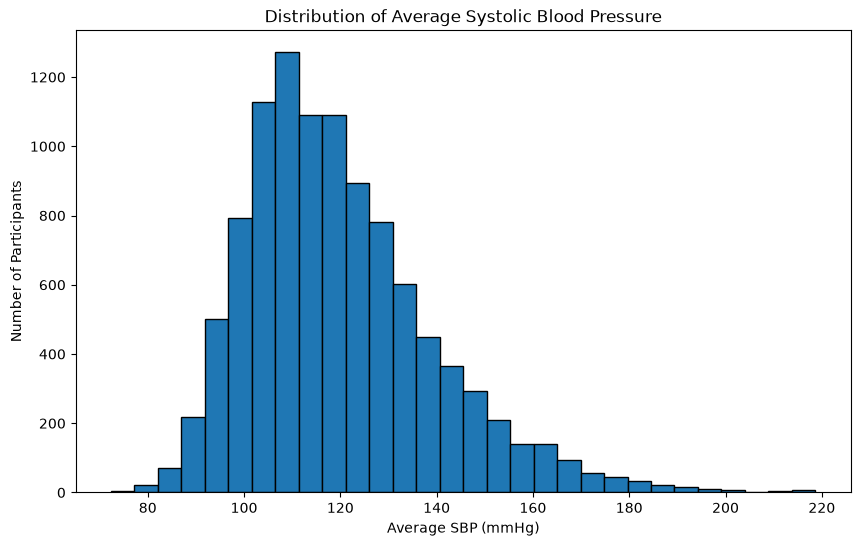

In [21]:
# Creating a histogram to visualize the distribution of Average Systolic Blood Pressure (SBP)

plt.figure(figsize=(10, 6))

plt.hist(
    model_training_df["Average_SBP"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Average Systolic Blood Pressure")
plt.xlabel("Average SBP (mmHg)")
plt.ylabel("Number of Participants")

plt.show()

Observations

* The distribution of Average_SBP is unimodal.
* The highest concentration of observations occurs around 110 mmHg.
* The distribution exhibits positive (right) skewness, with fewer participants having very high systolic blood pressure values.
* A small number of observations exceed 200 mmHg. These values are rare but remain within a clinically plausible range.

Interpretation

* The observed distribution is consistent with expectations for a population-based health survey.
* Right skewness reflects the relatively low prevalence of severe hypertension compared with normal blood pressure.
* No immediate evidence suggests erroneous target values requiring removal.
* Extreme systolic blood pressure values should be retained unless subsequent investigation identifies data quality issues.

/var/folders/9f/48g73zk123vbprx9zdt4gdz00000gn/T/ipykernel_72997/4239803420.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


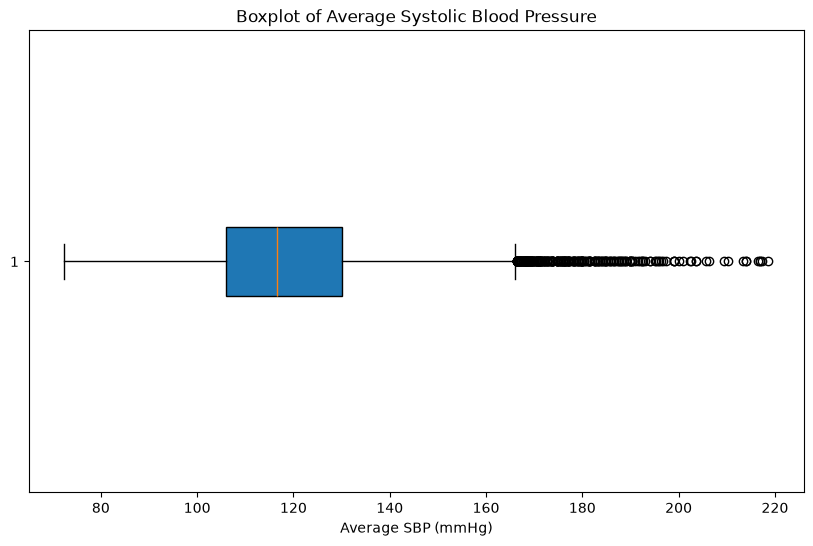

count    10353.000000
mean       119.810103
std         19.473950
min         72.333333
25%        106.000000
50%        116.666667
75%        130.000000
max        218.666667
Name: Average_SBP, dtype: float64

In [22]:
# Creating a boxplot to visualize the distribution of Average Systolic Blood Pressure (SBP)

plt.figure(figsize=(10, 6))

plt.boxplot(
    model_training_df["Average_SBP"],
    vert=False,
    patch_artist=True
)

plt.title("Boxplot of Average Systolic Blood Pressure")
plt.xlabel("Average SBP (mmHg)")

plt.show()

model_training_df["Average_SBP"].describe()

Observations

* The middle 50% of participants have an Average_SBP between 106 and 130 mmHg.
* The median Average_SBP is 116.67 mmHg.
* The mean (119.81 mmHg) is greater than the median, supporting a right-skewed distribution.
* The lower fence is 70 mmHg, and no observations fall below this threshold.
* The upper fence is 166 mmHg, with multiple observations beyond the upper whisker.

Interpretation

* The box plot confirms the histogram’s finding of a positively skewed distribution.
* Observations above the upper fence are statistically unusual but remain clinically plausible for patients with severe hypertension.
* There is currently no evidence that these observations represent data entry errors or measurement artifacts.

Project Impact

* No observations will be removed based solely on the box plot.
* Extreme SBP values will remain in the training dataset unless future investigation identifies data quality issues.

## EDA 5 – Age (RIDAGEYR)

### Objective

Understand the distribution and quality of the Age variable before evaluating its relationship with Average_SBP.

### Why this analysis?

Age is a clinically important predictor of blood pressure. Before using it in model development, we need to verify its completeness, distribution, and plausibility within the finalized training dataset.

### Method

Examine summary statistics and visualize the distribution of Age using the training dataset.

### Expected Outcome

- Confirm the age range of the training population.
- Verify the absence of missing values.
- Understand how participants are distributed across ages.

In [23]:
# 1. Summary statistics of Age
model_training_df["RIDAGEYR"].describe()

count    10353.000000
mean        41.040954
std         22.403663
min          8.000000
25%         19.000000
50%         41.000000
75%         61.000000
max         80.000000
Name: RIDAGEYR, dtype: float64

In [24]:
# 2. Missing values
model_training_df["RIDAGEYR"].isna().sum()

np.int64(0)

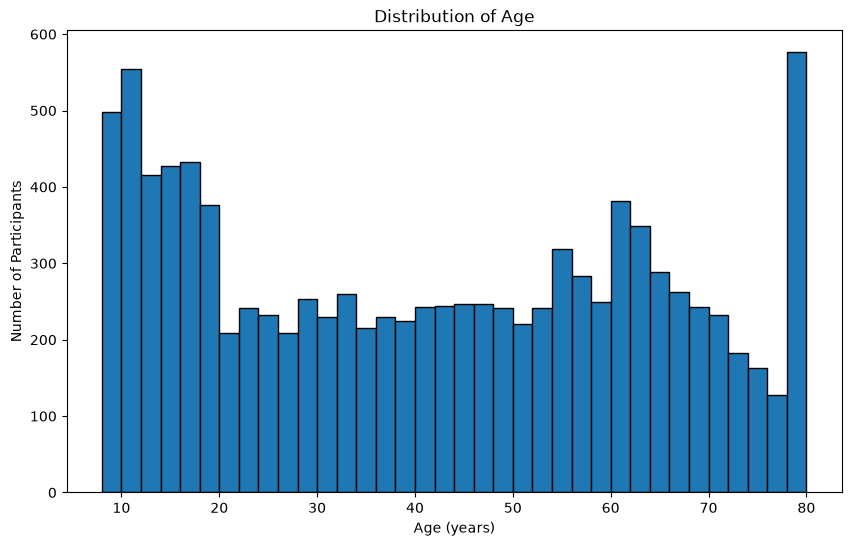

In [25]:
# 3. Histogram of Age Distribution
plt.figure(figsize=(10, 6))

plt.hist(
    model_training_df["RIDAGEYR"],
    bins=36,
    edgecolor="black"
)  
plt.title("Distribution of Age")
plt.xlabel("Age (years)")
plt.ylabel("Number of Participants")

plt.show()

In [26]:
age_counts = (
    model_training_df["RIDAGEYR"]
    .value_counts()
    .sort_index()
)

display(age_counts)

RIDAGEYR
8.0     243
9.0     255
10.0    279
11.0    275
12.0    198
       ... 
76.0     67
77.0     60
78.0     60
79.0     55
80.0    461
Name: count, Length: 73, dtype: int64

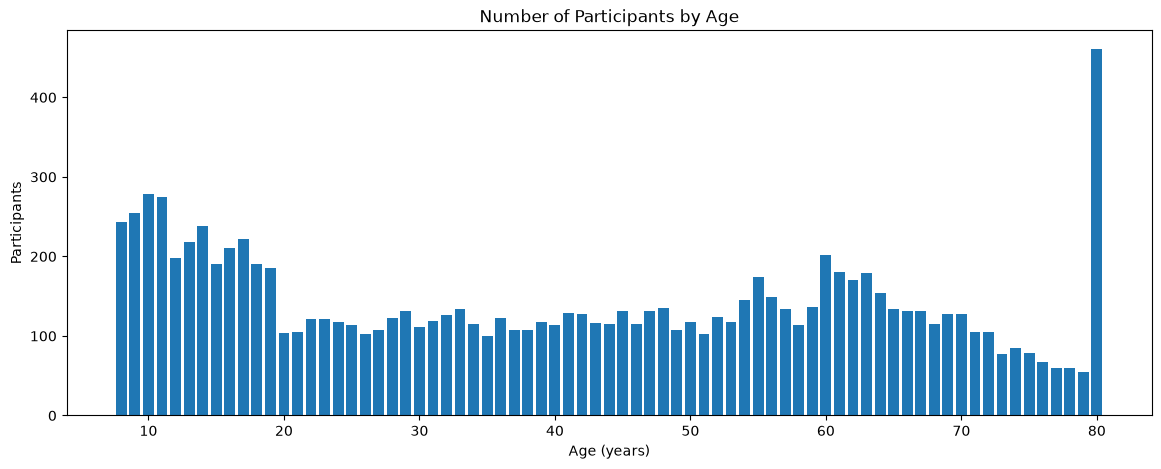

In [27]:
# 4. Bar chart of Age Distribution

age_counts = (
    model_training_df["RIDAGEYR"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(14,5))

plt.bar(
    age_counts.index,
    age_counts.values
)

plt.title("Number of Participants by Age")
plt.xlabel("Age (years)")
plt.ylabel("Participants")

plt.show()

Observations

* Participants span the full training age range (8 years through older adults).
* Younger participants (approximately ages 8–20) have somewhat higher representation than many middle-age groups.
* Participants aged 78 years and older also show relatively high representation.
* All ages included in the training dataset have sufficient observations for analysis.

Interpretation

* The age distribution is not uniform, which is expected in a complex health survey such as NHANES.
* There are no major gaps or sparsely represented age ranges that would prevent the model from learning age-related patterns.
* The observed distribution does not indicate a data quality issue.

Project Impact

No action required.

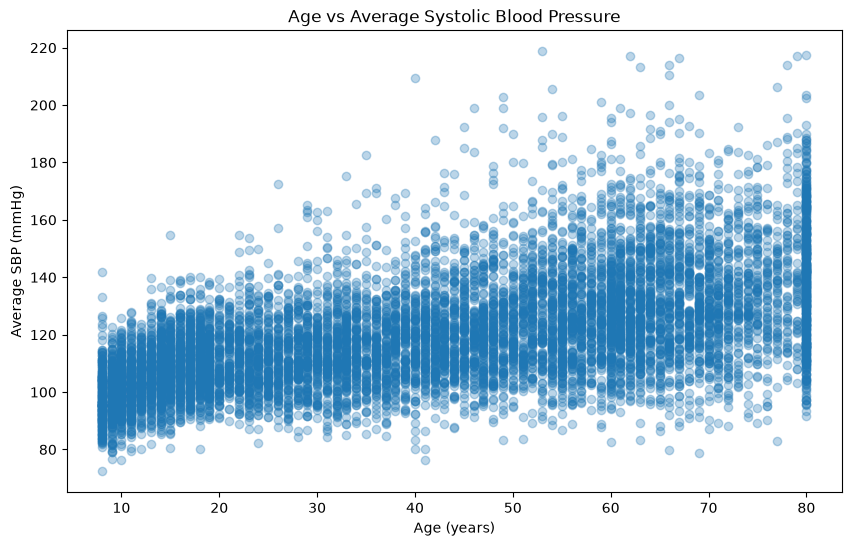

In [28]:
# 4. Scatter plot of Age vs Average Systolic Blood Pressure (SBP)

plt.figure(figsize=(10,6))

plt.scatter(
    model_training_df["RIDAGEYR"],
    model_training_df["Average_SBP"],
    alpha=0.3
)

plt.title("Age vs Average Systolic Blood Pressure")
plt.xlabel("Age (years)")
plt.ylabel("Average SBP (mmHg)")

plt.show()

In [29]:
# 5. Correlation between Age and Average Systolic Blood Pressure (SBP)

model_training_df["RIDAGEYR"].corr(
    model_training_df["Average_SBP"]
)

np.float64(0.5855157594269438)

Observations

* Pearson correlation between Age and Average_SBP is 0.5855.
* The correlation is positive and of moderate magnitude.
* The numerical result is consistent with the scatter plot.

Interpretation

* Age is an informative predictor of systolic blood pressure.
* The moderate correlation indicates that Age explains part—but not all—of the variability in SBP.
* Additional clinical predictors will be required to improve predictive performance.

Project Impact

* Retain Age as a continuous predictor.
* No additional preprocessing is required at this stage.
* Continue evaluating the remaining predictors.

## EDA 6 – BMI (BMXBMI)

### Objective

Understand the distribution and quality of the BMI variable before evaluating its relationship with Average_SBP.

### Why this analysis?

BMI can also affect blood pressure. Studies have shown that people with high BMI tends to have high BP. Before using it in model development, we need to verify its completeness, distribution, and plausibility within the finalized training dataset.

### Method

Examine summary statistics and visualize the distribution of BMI using the training dataset.

### Expected Outcome

- Confirm the BMI range of the training population.
- Verify the absence of missing values.
- Understand how participants are distributed across BMIs.

In [30]:
# 1. Summary statistics of BMIs

model_training_df["BMXBMI"].describe()

count    10263.000000
mean        28.212219
std          7.872907
min         12.500000
25%         22.700000
50%         27.200000
75%         32.400000
max         80.600000
Name: BMXBMI, dtype: float64

In [31]:
# 2. Missing values

model_training_df["BMXBMI"].isna().sum()

np.int64(90)

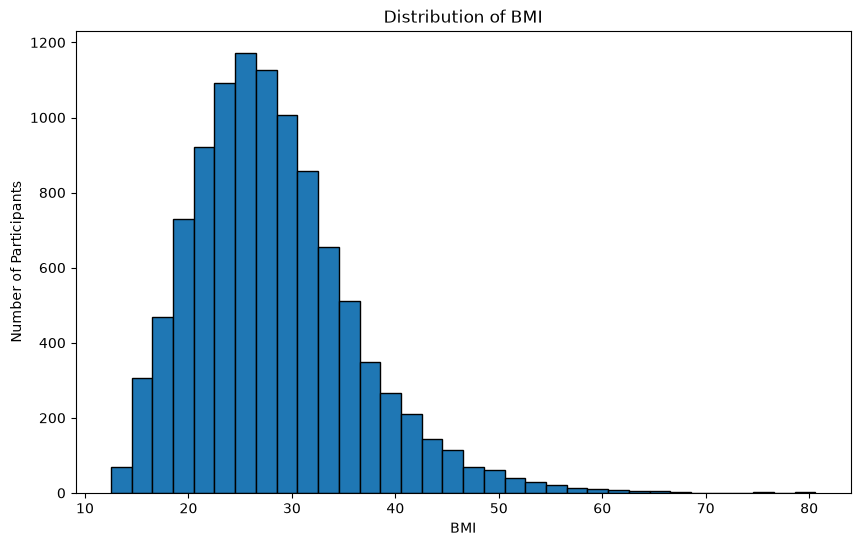

In [32]:
# 3. Histogram of BMI Distribution

plt.figure(figsize=(10, 6))
plt.hist(model_training_df["BMXBMI"], bins=34, edgecolor="black")
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Number of Participants")
plt.show()

In [33]:
bmi_counts = (
    model_training_df["BMXBMI"]
    .value_counts()
    .sort_index()
)

display(bmi_counts)

BMXBMI
12.5    1
13.0    1
13.1    1
13.2    3
13.3    3
       ..
72.9    1
74.8    1
75.7    1
78.6    1
80.6    1
Name: count, Length: 463, dtype: int64

Observations

* BMI contains 90 missing values (0.87%), representing a very small proportion of the training dataset.
* BMI ranges from 12.5 to 80.6 kg/m².
* The distribution is right-skewed with a small number of extreme values.
* Extreme BMI values appear as isolated observations but remain clinically plausible.

Interpretation

* No evidence suggests systematic data quality issues or impossible BMI measurements.
* The small proportion of missing values is unlikely to materially affect model development.

Project Decision

* Retain BMI as a predictor.
* Retain all observed BMI values.
* No preprocessing action is required at this stage.

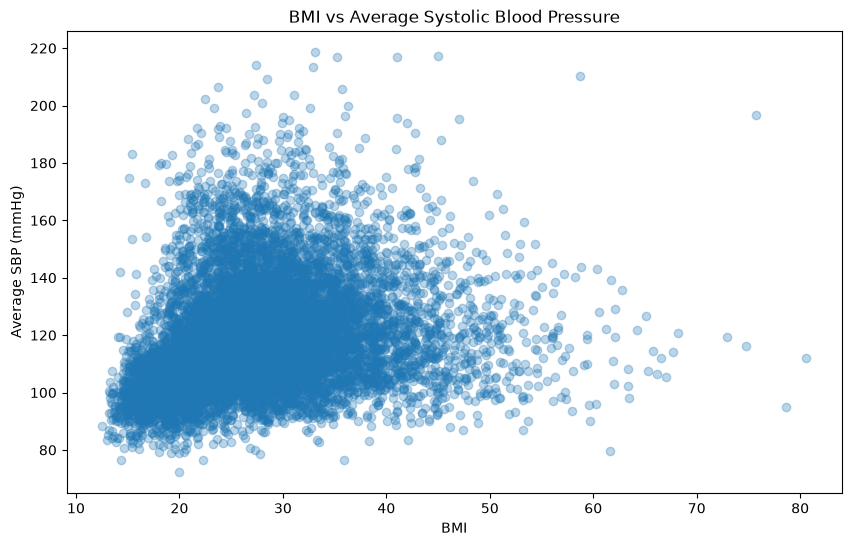

In [34]:
# 4. Scatter plot of BMI vs Average Systolic Blood Pressure (SBP)

plt.figure(figsize=(10,6))

plt.scatter(
    model_training_df["BMXBMI"],
    model_training_df["Average_SBP"],
    alpha=0.3
)

plt.title("BMI vs Average Systolic Blood Pressure")
plt.xlabel("BMI")
plt.ylabel("Average SBP (mmHg)")

plt.show()

In [35]:
# 5. Correlation between BMI and Average Systolic Blood Pressure (SBP)

model_training_df["BMXBMI"].corr(
    model_training_df["Average_SBP"]
)

np.float64(0.2147813099204087)

NOTE: Although BMI demonstrates only a weak positive relationship with Average_SBP (r ≈ 0.21), it will be retained as a candidate predictor for the baseline model. Its final inclusion will be determined after evaluating its contribution to model performance during model training.

## EDA 7 - Sex (RIAGENDR)

### Objective

Evaluate whether Sex (RIAGENDR) is a suitable candidate predictor for the baseline SBP prediction model by assessing its data quality, category distribution, and relationship with Average_SBP.

### Why this analysis?

Biological sex is a clinically relevant factor that may influence blood pressure due to physiological and hormonal differences. Before including it in the prediction model, we need to verify its data.

### Method

Verify category definitions and completeness, examine the distribution of male and female participants, and compare Average_SBP between the two groups using appropriate visualizations.

### Expected Outcome

* Confirm that RIAGENDR contains valid and complete category information.
* Understand the distribution of male and female participants in the training dataset.
* Determine whether Average_SBP differs meaningfully between the two groups.
* Decide whether Sex should be retained as a candidate predictor for the baseline model.

In [36]:
# 1. Summary statistics of Sex (RIAGENDR)

model_training_df["RIAGENDR"].value_counts()

RIAGENDR
2.0    5213
1.0    5140
Name: count, dtype: int64

In [37]:
model_training_df["RIAGENDR"].isna().sum()

np.int64(0)

Observation

* RIAGENDR contains two valid categories:
    * Male
    * Female
* No missing values or unexpected category codes were identified.

Limitation

* The dataset records only the categories defined by NHANES for this variable.
* The project does not have additional information to distinguish biological sex from gender identity or other related characteristics.

In [38]:
# 2. Calculate percentage of Sex (RIAGENDR) categories

model_training_df["RIAGENDR"].value_counts(normalize=True) * 100

RIAGENDR
2.0    50.352555
1.0    49.647445
Name: proportion, dtype: float64

Observation

* The training dataset consists of approximately 50.3% female and 49.7% male participants.
* No category is substantially underrepresented.

Interpretation

* The Sex variable is well balanced across both categories.
* No imbalance-related concerns are identified for this predictor.

Project Decision

* Retain the observed category distribution.
* No preprocessing or rebalancing is required.

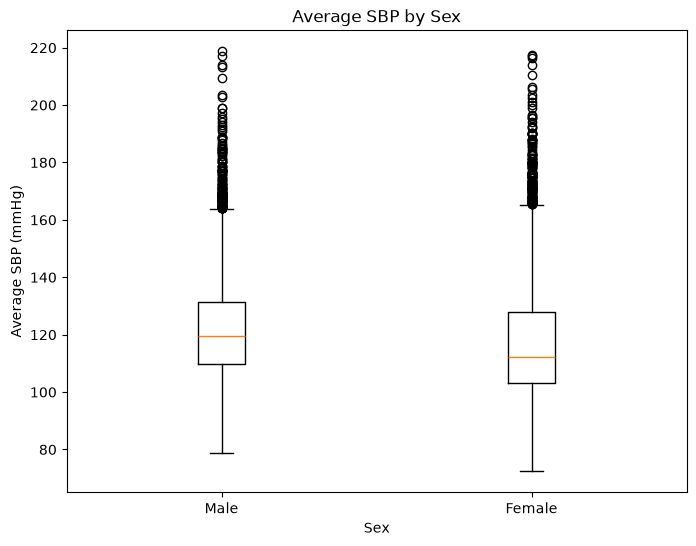

In [39]:
# 3. Box plot of Average Systolic Blood Pressure (SBP) by Sex (RIAGENDR)

male_sbp = model_training_df.loc[
    model_training_df["RIAGENDR"] == 1,
    "Average_SBP"
]

female_sbp = model_training_df.loc[
    model_training_df["RIAGENDR"] == 2,
    "Average_SBP"
]

plt.figure(figsize=(8,6))

plt.boxplot(
    [male_sbp, female_sbp],
    tick_labels=["Male", "Female"]   # if your Matplotlib version is older, use labels=
)

plt.title("Average SBP by Sex")
plt.xlabel("Sex")
plt.ylabel("Average SBP (mmHg)")

plt.show()


In [40]:
model_training_df.groupby("RIAGENDR")["Average_SBP"].describe()

,count,mean,std,min,25%,50%,75%,max
RIAGENDR,,,,,,,,
1.0,5140.0,122.180577,18.178871,78.666667,109.666667,119.666667,131.333333,218.666667
2.0,5213.0,117.472824,20.405451,72.333333,103.000000,112.333333,128.000000,217.333333


Observation

* Male participants have a higher mean (122.2 mmHg) and median (119.7 mmHg) Average_SBP than female participants (117.5 mmHg and 112.3 mmHg, respectively).
* The IQRs are similar, although the male distribution is shifted toward higher SBP values.
* The distributions overlap substantially.

Interpretation

* Sex is associated with differences in Average_SBP, with male participants generally exhibiting higher SBP.
* However, the large overlap between the two distributions indicates that Sex alone is not sufficient to accurately predict SBP.

Project Decision

* Retain Sex as a candidate predictor for the baseline model.
* Its contribution to predictive performance will be evaluated after model training.

## EDA 8 - Currently taking medication for high BP (BPQ050)


In [41]:
# ==========================================
# Check for number of partipants with age >= 16 years old
# ==========================================

adult_participants = model_training_df["RIDAGEYR"] >= 16

print("Number of adult participants:", adult_participants.sum())


Number of adult participants: 8457


In [42]:
print(model_training_df["Average_SBP"].describe())

print("\nMissing Average SBP:")
print(model_training_df["Average_SBP"].isna().sum())

print("\nAvailable Average SBP:")
print(model_training_df["Average_SBP"].notna().sum())

count    10353.000000
mean       119.810103
std         19.473950
min         72.333333
25%        106.000000
50%        116.666667
75%        130.000000
max        218.666667
Name: Average_SBP, dtype: float64

Missing Average SBP:
0

Available Average SBP:
10353


In [43]:
model_v1_df.loc[
    model_v1_df["RIDAGEYR"] >= 16,
    "Average_SBP"
].isna().sum()

np.int64(1738)

In [44]:
age_16_plus_total = (model_v1_df["RIDAGEYR"] >= 16).sum()

age_16_plus_with_sbp = (
    (model_v1_df["RIDAGEYR"] >= 16)
    & model_v1_df["Average_SBP"].notna()
).sum()

age_16_plus_without_sbp = (
    (model_v1_df["RIDAGEYR"] >= 16)
    & model_v1_df["Average_SBP"].isna()
).sum()

print("Age 16+ total:", age_16_plus_total)
print("Age 16+ with Average_SBP:", age_16_plus_with_sbp)
print("Age 16+ without Average_SBP:", age_16_plus_without_sbp)

Age 16+ total: 10195
Age 16+ with Average_SBP: 8457
Age 16+ without Average_SBP: 1738


In [45]:
# V1
model_v1_df.loc[
    model_v1_df["RIDAGEYR"] >= 16,
    "BPQ050A"
].value_counts(dropna=False)

BPQ050A
NaN    6916
1.0    2786
2.0     493
Name: count, dtype: int64

In [46]:
# Training
model_training_df.loc[
    model_training_df["RIDAGEYR"] >= 16,
    "BPQ050A"
].value_counts(dropna=False)

BPQ050A
NaN    5739
1.0    2315
2.0     403
Name: count, dtype: int64

NOTE: The high proportion of missing values in BPQ050 is due to the NHANES questionnaire skip pattern rather than incomplete data collection. Only participants previously diagnosed with hypertension and advised to take prescribed medication were eligible to answer this question. Consequently, the missing values are structural (not applicable) and do not represent data quality issues.

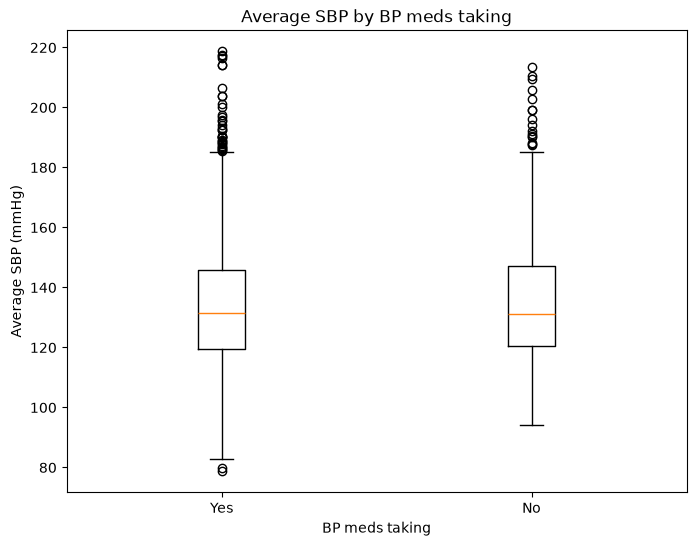

In [47]:
# 3. Box plot of Average Systolic Blood Pressure (SBP) by BP meds taking (BPQ050A)

male_sbp = model_training_df.loc[
    model_training_df["BPQ050A"] == 1,
    "Average_SBP"
]

female_sbp = model_training_df.loc[
    model_training_df["BPQ050A"] == 2,
    "Average_SBP"
]

plt.figure(figsize=(8,6))

plt.boxplot(
    [male_sbp, female_sbp],
    tick_labels=["Yes", "No"]   # if your Matplotlib version is older, use labels=
)

plt.title("Average SBP by BP meds taking")
plt.xlabel("BP meds taking")
plt.ylabel("Average SBP (mmHg)")

plt.show()

In [48]:
model_training_df.groupby("BPQ050A")["Average_SBP"].describe()

,count,mean,std,min,25%,50%,75%,max
BPQ050A,,,,,,,,
1.0,2315.0,133.558315,20.528518,78.666667,119.333333,131.333333,145.666667,218.666667
2.0,403.0,135.770058,22.690470,94.000000,120.333333,131.000000,147.000000,213.333333


NOTE: BP medication status does not produce a clear separation in Average SBP when considered independently. However, the feature remains clinically relevant and may provide complementary predictive information when combined with ot

## EDA 9 - Diabetes (DIQ010)

In [49]:
# V1
model_v1_df.loc[
    (model_v1_df["RIDAGEYR"] >= 1) & (model_v1_df["RIDAGEYR"] < 16),
    "DIQ010"
].value_counts(dropna=False)

DIQ010
2.0    4762
1.0      15
3.0      11
9.0       3
Name: count, dtype: int64

In [50]:
# V1
model_v1_df.loc[
    model_v1_df["RIDAGEYR"] >= 16,
    "DIQ010"
].value_counts(dropna=False)

DIQ010
2.0    8487
1.0    1430
3.0     273
9.0       5
Name: count, dtype: int64

In [51]:
# Training
model_training_df.loc[
    model_training_df["RIDAGEYR"] >= 16,
    "DIQ010"
].value_counts(dropna=False)

DIQ010
2.0    7035
1.0    1191
3.0     228
9.0       3
Name: count, dtype: int64

NOTE: DIQ010 is the initial question in the NHANES diabetes questionnaire and is administered to all eligible participants (ages 1–150), with no preceding questionnaire skip pattern. Comparison of the V1 and training datasets shows nearly identical distributions across all response categories, indicating that preprocessing (age restriction and removal of participants without Average SBP) did not materially alter the diabetes status distribution. Therefore, diabetes status is considered a reliable candidate feature for further analysis.

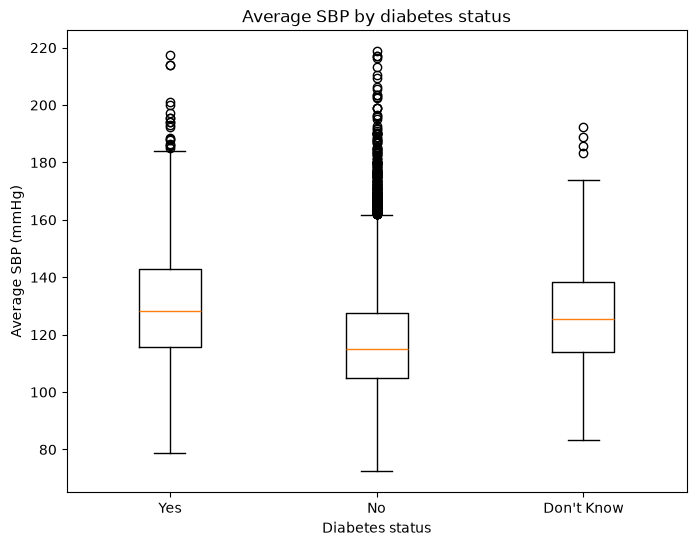

In [52]:
# 3. Box plot of Average Systolic Blood Pressure (SBP) by diabetes status (DIQ010)

Yes_sbp = model_training_df.loc[
    model_training_df["DIQ010"] == 1,
    "Average_SBP"
]

No_sbp = model_training_df.loc[
    model_training_df["DIQ010"] == 2,
    "Average_SBP"
]

DK_sbp = model_training_df.loc[
    model_training_df["DIQ010"] == 3,
    "Average_SBP"
]

plt.figure(figsize=(8,6))

plt.boxplot(
    [Yes_sbp, No_sbp, DK_sbp],
    tick_labels=["Yes", "No", "Don't Know"]   # if your Matplotlib version is older, use labels=
)

plt.title("Average SBP by diabetes status")
plt.xlabel("Diabetes status")
plt.ylabel("Average SBP (mmHg)")

plt.show()

In [53]:
model_training_df.groupby("DIQ010")["Average_SBP"].describe()

,count,mean,std,min,25%,50%,75%,max
DIQ010,,,,,,,,
1.0,1203.0,130.571349,21.149015,78.666667,115.666667,128.333333,143.000000,217.333333
2.0,8905.0,118.167584,18.700978,72.333333,105.000000,115.000000,127.666667,218.666667
3.0,239.0,127.253835,20.064641,83.333333,114.000000,125.333333,138.500000,192.333333
9.0,6.0,103.444444,6.891756,94.333333,97.916667,106.000000,107.333333,111.333333


NOTE: Participants with diabetes exhibit higher Average SBP than participants without diabetes. The entire central distribution, including the mean, median, and interquartile range, is shifted upward, indicating a positive association between diabetes status and Average SBP. Borderline diabetes falls between the two groups but more closely resembles participants with diabetes. Although this relationship is clinically consistent, the analysis is observational and does not imply that diabetes alone causes higher systolic blood pressure. Other clinical and demographic factors may also contribute to the observed differences.

In [54]:
feature_summary = pd.DataFrame({
    "Feature": [
        "Age",
        "Sex",
        "BMI",
        "Diabetes",
        "BP Medication"
    ],
    
    "Variable Type": [
        "Continuous",
        "Categorical",
        "Continuous",
        "Categorical",
        "Categorical"
    ],
    
    "Data Quality": [
        "Excellent",
        "Excellent",
        "Excellent",
        "Excellent",
        "Structural missingness explained"
    ],
    
    "Relationship with Avg SBP": [
        "Strong positive association",
        "Moderate difference",
        "Positive association",
        "Positive association",
        "Weak alone, clinically relevant"
    ],
    
    "Clinical Interpretation": [
        "Older participants generally have higher Avg SBP.",
        "Average SBP differs modestly between sexes.",
        "Higher BMI is associated with higher Avg SBP.",
        "Participants with diabetes show an upward shift in Avg SBP distribution.",
        "Medication status alone shows limited separation but remains clinically important."
    ],
    
    "Feature Decision": [
        "Retain",
        "Retain",
        "Retain",
        "Retain",
        "Retain"
    ]
})

feature_summary

,Feature,Variable Type,Data Quality,Relationship with Avg SBP,Clinical Interpretation,Feature Decision
0,Age,Continuous,Excellent,Strong positive association,Older participants generally have higher Avg SBP.,Retain
1,Sex,Categorical,Excellent,Moderate difference,Average SBP differs modestly between sexes.,Retain
2,BMI,Continuous,Excellent,Positive association,Higher BMI is associated with higher Avg SBP.,Retain
3,Diabetes,Categorical,Excellent,Positive association,Participants with diabetes show an upward shif...,Retain
4,BP Medication,Categorical,Structural missingness explained,"Weak alone, clinically relevant",Medication status alone shows limited separati...,Retain


# ==========================================
# Multivariable Analysis & Baseline Modeling
# ==========================================

In [55]:
# 1. Correlation Matrix between continuous features: Age, BMI, and Average Systolic Blood Pressure (SBP)

corr_matrix = model_training_df[["Average_SBP", "RIDAGEYR", "BMXBMI"]].corr()

corr_matrix

,Average_SBP,RIDAGEYR,BMXBMI
Average_SBP,1.000000,0.585516,0.214781
RIDAGEYR,0.585516,1.000000,0.304689
BMXBMI,0.214781,0.304689,1.000000


NOTE: The correlation analysis indicates that age has the strongest linear association with Average SBP (r = 0.586), while BMI demonstrates a weaker positive association (r = 0.215). Age and BMI exhibit a weak positive correlation (r = 0.305), suggesting that although the variables are related, they are not highly correlated. At this stage, there is no evidence of severe multicollinearity between the continuous predictors. Formal assessment using Variance Inflation Factors (VIF) will be performed during model diagnostics.

In [56]:
# 2. Relationship between categorical variables (Diabetes status and BP Medication)

model_training_df["DIQ010_label"] = model_training_df["DIQ010"].map({
    1: "Yes",
    2: "No",
    3: "Borderline"
})

model_training_df["BPQ050A_label"] = model_training_df["BPQ050A"].map({
    1: "Yes",
    2: "No"
})

diabetes_med_counts = pd.crosstab(
    model_training_df["DIQ010_label"],
    model_training_df["BPQ050A_label"]
)

diabetes_med_counts

diabetes_med_percent = pd.crosstab(
    model_training_df["DIQ010_label"],
    model_training_df["BPQ050A_label"],
    normalize="index"
).mul(100).round(2)

diabetes_med_percent

BPQ050A_label,No,Yes
DIQ010_label,,
Borderline,14.41,85.59
No,18.31,81.69
Yes,7.10,92.90


NOTE: The table shows an association between diabetes status and BP medication use. It does not establish that diabetes causes someone to take BP medication. Participants with diabetes may be more likely to have hypertension, which increases the likelihood of being prescribed BP medication. However, other factors such as age, BMI, cardiovascular disease, and clinical treatment decisions may also contribute to this relationship.

In [62]:
# Diabetes status and Sex

model_training_df["DIQ010_label"] = model_training_df["DIQ010"].map({
    1: "Yes",
    2: "No",
    3: "Borderline"
})

model_training_df["RIAGENDR_label"] = model_training_df["RIAGENDR"].map({
    1: "Male",
    2: "Female"
})

diabetes_sex_counts = pd.crosstab(
    model_training_df["DIQ010_label"],
    model_training_df["RIAGENDR_label"]
)

diabetes_sex_counts

diabetes_sex_percent = pd.crosstab(
    model_training_df["DIQ010_label"],
    model_training_df["RIAGENDR_label"],
    normalize="index"
).mul(100).round(2)

diabetes_sex_percent

RIAGENDR_label,Female,Male
DIQ010_label,,
Borderline,46.03,53.97
No,51.17,48.83
Yes,45.14,54.86


NOTE: The sex distribution was relatively balanced across all diabetes categories. Participants with diabetes were slightly more likely to be male (54.86%) than female (45.14%), while participants without diabetes had a nearly even sex distribution with a slight majority of females (51.17%). Overall, the differences were modest, suggesting no strong association between sex and diabetes status in this dataset.

In [63]:
# BP meds status and Sex

model_training_df["BPQ050A_label"] = model_training_df["BPQ050A"].map({
    1: "Yes",
    2: "No"
})

model_training_df["RIAGENDR_label"] = model_training_df["RIAGENDR"].map({
    1: "Male",
    2: "Female"
})

bp_meds_sex_counts = pd.crosstab(
    model_training_df["BPQ050A_label"],
    model_training_df["RIAGENDR_label"]
)

bp_meds_sex_counts

bp_meds_sex_percent = pd.crosstab(
    model_training_df["BPQ050A_label"],
    model_training_df["RIAGENDR_label"],
    normalize="index"
).mul(100).round(2)

bp_meds_sex_percent

RIAGENDR_label,Female,Male
BPQ050A_label,,
No,46.90,53.10
Yes,51.75,48.25


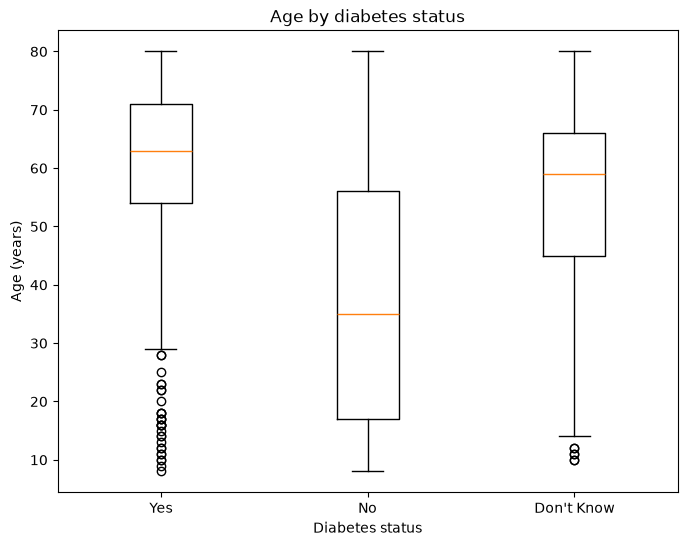

In [64]:
# 4. Cateforical variable and continuous variable relationship: Diabetes status with Age

Yes_sbp = model_training_df.loc[
    model_training_df["DIQ010"] == 1,
    "RIDAGEYR"
]

No_sbp = model_training_df.loc[
    model_training_df["DIQ010"] == 2,
    "RIDAGEYR"
]

DK_sbp = model_training_df.loc[
    model_training_df["DIQ010"] == 3,
    "RIDAGEYR"
]

plt.figure(figsize=(8,6))

plt.boxplot(
    [Yes_sbp, No_sbp, DK_sbp],
    tick_labels=["Yes", "No", "Don't Know"]   # if your Matplotlib version is older, use labels=
)

plt.title("Age by diabetes status")
plt.xlabel("Diabetes status")
plt.ylabel("Age (years)")

plt.show()

In [ ]:
model_training_df.groupby("DIQ010_label")["RIDAGEYR"].describe()

,count,mean,std,min,25%,50%,75%,max
DIQ010_label,,,,,,,,
Borderline,239.0,54.569038,18.267229,10.0,45.0,59.0,66.0,80.0
No,8905.0,37.922403,21.851921,8.0,17.0,35.0,56.0,80.0
Yes,1203.0,61.530341,13.700433,8.0,54.0,63.0,71.0,80.0


NOTE: Participants with diabetes were substantially older than participants without diabetes. The median age was 63 years for the diabetes group compared with 35 years for the non-diabetes group, indicating a pronounced shift in the age distribution. The borderline diabetes group closely resembled the diabetes group, with a median age of 59 years. These findings suggest a strong association between age and diabetes status, indicating that age may partially account for the relationship between diabetes and Average SBP observed in the feature-level analysis.

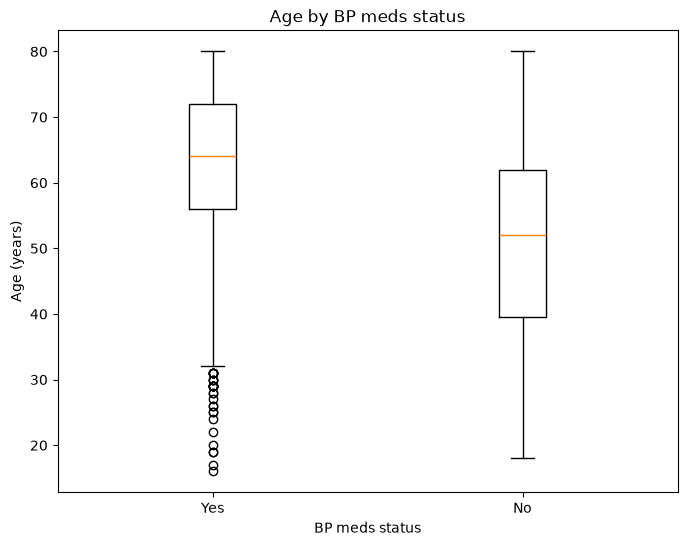

,count,mean,std,min,25%,50%,75%,max
BPQ050A_label,,,,,,,,
No,403.0,51.034739,14.976060,18.0,39.5,52.0,62.0,80.0
Yes,2315.0,63.187905,12.094615,16.0,56.0,64.0,72.0,80.0


In [68]:
# Age vs BP meds status

Yes_sbp = model_training_df.loc[
    model_training_df["BPQ050A"] == 1,
    "RIDAGEYR"
]

No_sbp = model_training_df.loc[
    model_training_df["BPQ050A"] == 2,
    "RIDAGEYR"
]

plt.figure(figsize=(8,6))

plt.boxplot(
    [Yes_sbp, No_sbp],
    tick_labels=["Yes", "No"]   # if your Matplotlib version is older, use labels=
)

plt.title("Age by BP meds status")
plt.xlabel("BP meds status")
plt.ylabel("Age (years)")

plt.show()

model_training_df.groupby("BPQ050A_label")["RIDAGEYR"].describe()

NOTE: Participants taking BP medication were older than participants not taking BP medication. The median age was 64 years for participants taking BP medication compared with 52 years for those not taking medication, indicating a clear upward shift in the age distribution. These findings suggest a strong association between age and BP medication use, indicating that age may partially account for the relationship between BP medication use and Average SBP observed in the feature-level analysis.

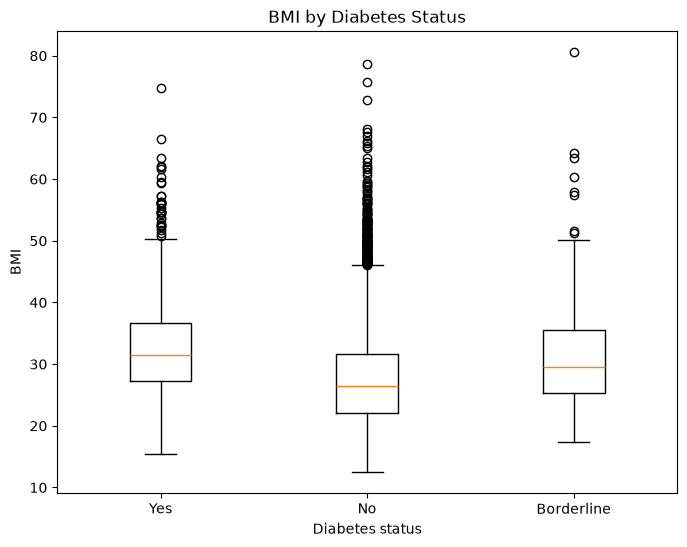

,count,mean,std,min,25%,50%,75%,max
DIQ010_label,,,,,,,,
Borderline,237.0,31.637975,8.830753,17.4,25.3,29.5,35.6,80.6
No,8835.0,27.523475,7.644253,12.5,22.1,26.5,31.7,78.6
Yes,1185.0,32.673586,7.720595,15.4,27.3,31.5,36.6,74.8


In [77]:
# 4. Cateforical variable and continuous variable relationship: Diabetes status with BMI

Yes_bmi = model_training_df.loc[
    model_training_df["DIQ010"] == 1,
    "BMXBMI"
].dropna()

No_bmi = model_training_df.loc[
    model_training_df["DIQ010"] == 2,
    "BMXBMI"
].dropna()

Borderline_bmi = model_training_df.loc[
    model_training_df["DIQ010"] == 3,
    "BMXBMI"
].dropna()

plt.figure(figsize=(8, 6))

plt.boxplot(

    [Yes_bmi, No_bmi, Borderline_bmi],

    tick_labels=["Yes", "No", "Borderline"]

)

plt.title("BMI by Diabetes Status")

plt.xlabel("Diabetes status")

plt.ylabel("BMI")

plt.show()

model_training_df.groupby("DIQ010_label")["BMXBMI"].describe()

NOTE: Participants with diabetes had higher BMI values than participants without diabetes. The median BMI was 31.5 kg/m² for the diabetes group compared with 26.5 kg/m² for the non-diabetes group, indicating an upward shift in the BMI distribution. Participants with borderline diabetes closely resembled those with diabetes, with a median BMI of 29.5 kg/m². These findings suggest a positive association between diabetes status and BMI, indicating that BMI may partially account for the relationship between diabetes and Average SBP observed in the feature-level analysis.

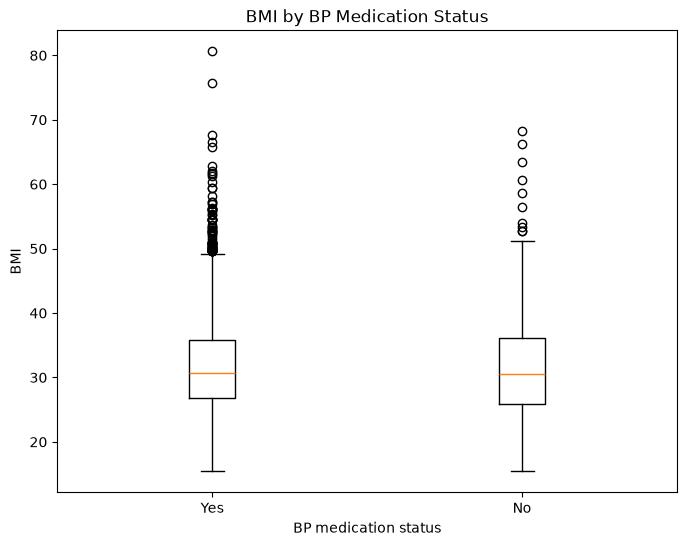

,count,mean,std,min,25%,50%,75%,max
BPQ050A_label,,,,,,,,
No,394.0,31.924873,8.516273,15.4,25.9,30.6,36.2,68.2
Yes,2287.0,31.984040,7.504098,15.4,26.8,30.7,35.8,80.6


In [79]:
# BP medication status and BMI

Yes_bmi = model_training_df.loc[
    model_training_df["BPQ050A"] == 1,
    "BMXBMI"
].dropna()

No_bmi = model_training_df.loc[
    model_training_df["BPQ050A"] == 2,
    "BMXBMI"
].dropna()

plt.figure(figsize=(8, 6))

plt.boxplot(
    [Yes_bmi, No_bmi],
    tick_labels=["Yes", "No"]
)

plt.title("BMI by BP Medication Status")
plt.xlabel("BP medication status")
plt.ylabel("BMI")

plt.show()

model_training_df.groupby("BPQ050A_label")["BMXBMI"].describe()

NOTE: There was little difference in BMI between participants taking BP medication and those not taking BP medication. The median BMI was nearly identical for both groups (30.7 kg/m² vs. 30.6 kg/m²), and the distributions exhibited substantial overlap. These findings suggest only a weak association between BMI and BP medication use in this dataset.

## Multivariable EDA Summary

| Relationship | Strength | Key Findings | Modeling Implication |
|--------------|----------|--------------|----------------------|
| **Age ↔ Diabetes** | **Strong** | Participants with diabetes were substantially older than those without diabetes. The borderline group closely resembled the diabetes group. | Age may partially explain the relationship between diabetes and Average SBP. |
| **Age ↔ BP Medication** | **Strong** | Participants taking BP medication were considerably older than those not taking medication. | Age may partially explain the relationship between BP medication use and Average SBP. |
| **BMI ↔ Diabetes** | **Moderate** | Participants with diabetes had higher BMI values than participants without diabetes, with the borderline group closely resembling the diabetes group. | BMI may partially explain the relationship between diabetes and Average SBP. |
| **Diabetes ↔ BP Medication** | **Moderate** | Participants with diabetes were more likely to report taking BP medication than participants without diabetes. | Diabetes and BP medication may provide complementary clinical information in the regression model. |
| **Age ↔ BMI** | **Weak** | Age and BMI showed a weak positive correlation (r = 0.305), indicating they capture different aspects of patient health. | Low concern for multicollinearity; retain both predictors. |
| **BMI ↔ BP Medication** | **Weak** | BMI distributions were nearly identical between BP medication groups. | BMI is unlikely to confound the relationship between BP medication use and Average SBP. |
| **Sex ↔ Diabetes** | **Weak** | Sex distribution was relatively balanced across diabetes categories with only modest differences. | Sex and diabetes appear largely independent in this dataset. |
| **Sex ↔ BP Medication** | **Weak** | Sex distribution was similar between BP medication groups. | Little evidence of a strong association between sex and BP medication use. |

# Baseline Linear Regression Model

## Objective

The objective of the baseline model is to establish an interpretable reference model for predicting Average Systolic Blood Pressure (Average SBP). This model will quantify the independent relationship between each predictor and Average SBP while controlling for the other predictors. The baseline model also serves as a benchmark for evaluating future model improvements.

## Observation Unit

Each observation represents one patient from the cleaned NHANES dataset.

## Target Variable

- Average SBP (mmHg)

## Predictor Variables

- Age (RIDAGEYR)
- BMI (BMXBMI)
- Sex (RIAGENDR)
- Diabetes Status (DIQ010)
- BP Medication Use (BPQ050A)

## Model Specification

Average SBP = β₀ + β₁(Age) + β₂(BMI) + β₃(Sex) + β₄(Diabetes) + β₅(BP Medication) + ε

In [81]:
formula = """
Average_SBP ~
RIDAGEYR +
BMXBMI +
C(RIAGENDR) +
C(DIQ010) +
C(BPQ050A)
"""

In [87]:
print(model_training_df.columns.tolist())

['SEQN', 'RIDAGEYR', 'RIAGENDR', 'BMXBMI', 'BPXOSY1', 'BPXOSY2', 'BPXOSY3', 'BPXODI1', 'BPXODI2', 'BPXODI3', 'BPQ050A', 'DIQ010', 'Average_SBP', 'Average_DBP', 'SBP_Range', 'DIQ010_label', 'BPQ050A_label', 'RIAGENDR_label']


In [89]:
baseline_model = smf.ols(
    formula=formula,
    data=model_training_df
).fit()

baseline_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            Average_SBP   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     22.15
Date:                Sat, 18 Jul 2026   Prob (F-statistic):           1.41e-25
Time:                        16:57:17   Log-Likelihood:                -11856.
No. Observations:                2681   AIC:                         2.373e+04
Df Residuals:                    2674   BIC:                         2.377e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            118.0417      3.157     37.387      0.000     111.851     124.233
C(RIAGENDR)[T.2.0]     0.9364      0.789      1.187      0.235      -0.611       2.483
C(DIQ010)[T.2.0]       1.0627      0.893      1.190      0.234      -0.688       2.814
C(DIQ010)[T.3.0]       1.1267      2.007      0.562      0.574      -2.808       5.061
C(DIQ010)[T.9.0]    7.103e-17   9.65e-16      0.074      0.941   -1.82e-15    1.96e-15
C(BPQ050A)[T.2.0]      5.6243      1.174      4.792      0.000       3.323       7.926
RIDAGEYR               0.3120      0.032      9.677      0.000       0.249       0.375
BMXBMI                -0.1723      0.054     -3.219      0.001      -0.277      -0.067
==============================================================================
Omnibus:                      141.174   Durbin-Watson:                   2.032
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              173.773
Skew:                           0.533   Prob(JB):                     1.84e-38
Kurtosis:                       3.649   Cond. No.                     3.03e+19
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.44e-32. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

# =======================================
# MODELING DATASET
# =======================================

# =======================================
# MODEL DEPLOYMENT
# =======================================

# =======================================
# CONCLUSION
# =======================================